In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from numpy import sqrt
import matplotlib
from matplotlib import gridspec
from matplotlib.pyplot import *

from mpl_toolkits.axes_grid1 import make_axes_locatable

def latexify(fig_width=None, fig_height=None, columns=1):
    """Set up matplotlib's RC params for LaTeX plotting.
    Call this before plotting a figure.

    Parameters
    ----------
    fig_width : float, optional, inches
    fig_height : float,  optional, inches
    columns : {1, 2}
    """

    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    assert(columns in [1,2])

    if fig_width is None:
        fig_width = 3.39 if columns==1 else 6.9 # width in inches

    if fig_height is None:
        golden_mean = (sqrt(5)-1.0)/2.0    # Aesthetic ratio
        fig_height = fig_width*golden_mean # height in inches

    #MAX_HEIGHT_INCHES = 7.0
    #if fig_height > MAX_HEIGHT_INCHES:
    #    print("WARNING: fig_height too large:" + fig_height + 
    #          "so will reduce to" + MAX_HEIGHT_INCHES + "inches.")
    #    fig_height = MAX_HEIGHT_INCHES

    params = {'backend': 'ps',
              'text.latex.preamble': [r'\usepackage{gensymb}'],
              'axes.labelsize': 8, # fontsize for x and y labels (was 10)
              'axes.titlesize': 8,
              'font.size': 8, # was 10
              'legend.fontsize': 8, # was 10
              'xtick.labelsize': 8,
              'ytick.labelsize': 8,
              'text.usetex': True,
              'figure.figsize': [fig_width,fig_height],
              'font.family': 'serif',
              'figure.autolayout': True,
              'lines.linewidth' : 1.0
    }

    matplotlib.rcParams.update(params)


def format_axes(ax):
    
    SPINE_COLOR = 'gray'

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(SPINE_COLOR)
        ax.spines[spine].set_linewidth(0.5)

    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_tick_params(direction='out', color=SPINE_COLOR)

    return ax

In [2]:
import numpy as np
import matplotlib.pyplot as plt
aG = 2.4602
acc = aG/np.sqrt(3.0)
def crossProduct(ourpoint, point1, point2):
    x1 = point1[0]
    y1 = point1[1]
    x2 = point2[0]
    y2 = point2[1]
    xA = ourpoint[0]
    yA = ourpoint[1]
    v1 = (x2-x1, y2-y1)   # Vector 1
    v2 = (x2-xA, y2-yA)   # Vector 1
    crossProd = v1[0]*v2[1] - v1[1]*v2[0] 
    return crossProd
def insideAAbis(ourpoint,rAAp,rAApp):
    A = np.array([rAAp,0])
    B = np.array([rAAp/2.0,rAApp])
    C = np.array([-rAAp/2.0,rAApp])
    D = np.array([-rAAp,0])
    E = np.array([-rAAp/2.0,-rAApp])
    F = np.array([rAAp/2.0,-rAApp])
    if np.logical_and(np.less_equal(crossProduct(ourpoint,A,B),0.0), np.less_equal(crossProduct(ourpoint,B,C),0.0)):
        if np.logical_and(np.less_equal(crossProduct(ourpoint,C,D),0.0), np.less_equal(crossProduct(ourpoint,D,E),0.0)):
            if np.logical_and(np.less_equal(crossProduct(ourpoint,E,F),0.0), np.less_equal(crossProduct(ourpoint,F,A),0.0)):
                return np.array([True])
            else:
                return np.array([False])
        else:
            return np.array([False])
    else:
        return np.array([False])
    
def insideABbis(ourpointO,rAAp,rAApp):
    #ourpoint = np.array([ourpoint[0] - aCC,ourpoint[1]])
    d1 = np.sqrt(acc**2 - (acc/2.0)**2)
    d2 = 3.0/4.0*acc
    A = np.array([rAAp,0])
    B = np.array([rAAp/2.0,rAApp])
    C = np.array([-rAAp/2.0,rAApp])
    D = np.array([-rAAp,0])
    E = np.array([-rAAp/2.0,-rAApp])
    F = np.array([rAAp/2.0,-rAApp])
    #ourpointVec = [np.array([ourpointO[0]- acc ,ourpointO[1]]),
    #                 np.array([ourpointO[0]+acc/2.0,ourpointO[1]+aG/2]),
    #                 np.array([ourpointO[0]+acc/2.0,ourpointO[1]-aG/2])]
    ourpointVec = [np.array([ourpointO[0] ,ourpointO[1]- acc]),
                     np.array([ourpointO[0]+aG/2,ourpointO[1]+acc/2.0]),
                     np.array([ourpointO[0]-aG/2,ourpointO[1]+acc/2.0])]
    for ourpoint in ourpointVec:
        if np.logical_and(np.less_equal(crossProduct(ourpoint,A,B),0.0), np.less_equal(crossProduct(ourpoint,B,C),0.0)):
            if np.logical_and(np.less_equal(crossProduct(ourpoint,C,D),0.0), np.less_equal(crossProduct(ourpoint,D,E),0.0)):
                if np.logical_and(np.less_equal(crossProduct(ourpoint,E,F),0.0), np.less_equal(crossProduct(ourpoint,F,A),0.0)):
                    status = np.array([True])
                    break
                else:
                    status = np.array([False])
            else:
                status = np.array([False])
        else:
            status = np.array([False])
            
    return status
    
    
def insideBAbis(ourpointO,rAAp,rAApp):
    #ourpoint = np.array([ourpoint[0] - aCC,ourpoint[1]])
    d1 = np.sqrt(acc**2 - (acc/2.0)**2)
    d2 = 3.0/4.0*acc
    A = np.array([rAAp,0])
    B = np.array([rAAp/2.0,rAApp])
    C = np.array([-rAAp/2.0,rAApp])
    D = np.array([-rAAp,0])
    E = np.array([-rAAp/2.0,-rAApp])
    F = np.array([rAAp/2.0,-rAApp])

    ourpointVec = [np.array([ourpointO[0],ourpointO[1]+ acc ]),
                     np.array([ourpointO[0]+aG/2,ourpointO[1]-acc/2.0]),
                     np.array([ourpointO[0]-aG/2,ourpointO[1]-acc/2.0])]
    for ourpoint in ourpointVec:
        if np.logical_and(np.less_equal(crossProduct(ourpoint,A,B),0.0), np.less_equal(crossProduct(ourpoint,B,C),0.0)):
            if np.logical_and(np.less_equal(crossProduct(ourpoint,C,D),0.0), np.less_equal(crossProduct(ourpoint,D,E),0.0)):
                if np.logical_and(np.less_equal(crossProduct(ourpoint,E,F),0.0), np.less_equal(crossProduct(ourpoint,F,A),0.0)):
                    status = np.array([True])
                    break
                else:
                    status = np.array([False])
            else:
                status = np.array([False])
        else:
            status = np.array([False])
    
    return status
        
        
def insideSP1bis(ourpointO,rAA,w1,rAAp,rAApp):
    #ourpoint = np.array([ourpoint[0] - aCC,ourpoint[1]])
    A0 = np.array([rAA/2,0])
    B0 = np.array([rAAp/2.0,w1/2])
    C0 = np.array([-rAAp/2.0,w1/2])
    D0 = np.array([-rAA/2,0])
    E0 = np.array([-rAAp/2.0,-w1/2])
    F0 = np.array([rAAp/2.0,-w1/2])
    theta = -60*np.pi/180
    R = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
    AR1 = np.matmul(R,A0)
    BR1 = np.matmul(R,B0)
    CR1 = np.matmul(R,C0)
    DR1 = np.matmul(R,D0)
    ER1 = np.matmul(R,E0)
    FR1 = np.matmul(R,F0)
    theta = 60*np.pi/180
    R = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
    AR2 = np.matmul(R,A0)
    BR2 = np.matmul(R,B0)
    CR2 = np.matmul(R,C0)
    DR2 = np.matmul(R,D0)
    ER2 = np.matmul(R,E0)
    FR2 = np.matmul(R,F0)
    ourpointVec = [np.array([ourpointO[0] ,ourpointO[1]- acc/2.0]),
                     np.array([ourpointO[0]+aG/4,ourpointO[1]+acc/4.0]),
                     np.array([ourpointO[0]-aG/4,ourpointO[1]+acc/4.0])]
    for ourpoint,pointvec in zip(ourpointVec, [[A0,B0,C0,D0,E0,F0],[AR1,BR1,CR1,DR1,ER1,FR1],[AR2,BR2,CR2,DR2,ER2,FR2]]):
        #A,B,C,D,E,F = pointvec
        A,B,C,D,E,F = pointvec
        if np.logical_and(np.less_equal(crossProduct(ourpoint,A,B),0.0), np.less_equal(crossProduct(ourpoint,B,C),0.0)):
            if np.logical_and(np.less_equal(crossProduct(ourpoint,C,D),0.0), np.less_equal(crossProduct(ourpoint,D,E),0.0)):
                if np.logical_and(np.less_equal(crossProduct(ourpoint,E,F),0.0), np.less_equal(crossProduct(ourpoint,F,A),0.0)):
                    status = np.array([True])
                    break
                else:
                    status = np.array([False])
            else:
                status = np.array([False])
        else:
            status = np.array([False])
            
    return status
        
def insideSP2bis(ourpointO,rAA,w1,rAAp,rAApp):
    A0 = np.array([rAA/2,0])
    B0 = np.array([rAAp/2.0,w1/2])
    C0 = np.array([-rAAp/2.0,w1/2])
    D0 = np.array([-rAA/2,0])
    E0 = np.array([-rAAp/2.0,-w1/2])
    F0 = np.array([rAAp/2.0,-w1/2])
    theta = 60*np.pi/180
    R = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
    AR1 = np.matmul(R,A0)
    BR1 = np.matmul(R,B0)
    CR1 = np.matmul(R,C0)
    DR1 = np.matmul(R,D0)
    ER1 = np.matmul(R,E0)
    FR1 = np.matmul(R,F0)
    theta = -60*np.pi/180
    R = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
    AR2 = np.matmul(R,A0)
    BR2 = np.matmul(R,B0)
    CR2 = np.matmul(R,C0)
    DR2 = np.matmul(R,D0)
    ER2 = np.matmul(R,E0)
    FR2 = np.matmul(R,F0)
    #ourpointVec = [np.array([ourpointO[0]- acc/2.0 ,ourpointO[1]]),
    #                 np.array([ourpointO[0]+acc/4.0,ourpointO[1]+aG/4]),
    #                 np.array([ourpointO[0]+acc/4.0,ourpointO[1]-aG/4])]
    ourpointVec = [np.array([ourpointO[0] ,ourpointO[1]+ acc/2.0]),
                     np.array([ourpointO[0]+aG/4,ourpointO[1]-acc/4.0]),
                     np.array([ourpointO[0]-aG/4,ourpointO[1]-acc/4.0])]
    for ourpoint,pointvec in zip(ourpointVec, [[A0,B0,C0,D0,E0,F0],[AR1,BR1,CR1,DR1,ER1,FR1],[AR2,BR2,CR2,DR2,ER2,FR2]]):
        #A,B,C,D,E,F = pointvec
        A,B,C,D,E,F= pointvec    
        if np.logical_and(np.less_equal(crossProduct(ourpoint,A,B),0.0), np.less_equal(crossProduct(ourpoint,B,C),0.0)):
            if np.logical_and(np.less_equal(crossProduct(ourpoint,C,D),0.0), np.less_equal(crossProduct(ourpoint,D,E),0.0)):
                if np.logical_and(np.less_equal(crossProduct(ourpoint,E,F),0.0), np.less_equal(crossProduct(ourpoint,F,A),0.0)):
                    status = np.array([True])
                    break
                else:
                    status = np.array([False])
            else:
                status = np.array([False])
        else:
            status = np.array([False])
            
    return status
        
def insideSP3bis(ourpointO,rAA,w1,rAAp,rAApp):
    #ourpoint = np.array([ourpoint[0] - aCC,ourpoint[1]])
    A0 = np.array([rAA/2,0])
    B0 = np.array([rAAp/2.0,w1/2])
    C0 = np.array([-rAAp/2.0,w1/2])
    D0 = np.array([-rAA/2,0])
    E0 = np.array([-rAAp/2.0,-w1/2])
    F0 = np.array([rAAp/2.0,-w1/2])
    theta = 60*np.pi/180
    R = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
    AR1 = np.matmul(R,A0)
    BR1 = np.matmul(R,B0)
    CR1 = np.matmul(R,C0)
    DR1 = np.matmul(R,D0)
    ER1 = np.matmul(R,E0)
    FR1 = np.matmul(R,F0)
    theta = -60*np.pi/180
    R = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
    AR2 = np.matmul(R,A0)
    BR2 = np.matmul(R,B0)
    CR2 = np.matmul(R,C0)
    DR2 = np.matmul(R,D0)
    ER2 = np.matmul(R,E0)
    FR2 = np.matmul(R,F0)
    theta = -180*np.pi/180

    
    ourpointVec = [np.array([ourpointO[0]-aG/2,ourpointO[1]]),
                   np.array([ourpointO[0]+aG/2,ourpointO[1]]),
                   np.array([ourpointO[0]-aG/4,ourpointO[1]-acc*3.0/4.0]),
                    np.array([ourpointO[0]+aG/4,ourpointO[1]+acc*3.0/4.0]),
                    np.array([ourpointO[0]+aG/4,ourpointO[1]-acc*3.0/4.0]),
                     np.array([ourpointO[0]-aG/4,ourpointO[1]+acc*3.0/4.0])]
    for ourpoint,pointvec in zip(ourpointVec, [[A0,B0,C0,D0,E0,F0],[A0,B0,C0,D0,E0,F0],
                                              [AR1,BR1,CR1,DR1,ER1,FR1],[AR1,BR1,CR1,DR1,ER1,FR1],
                                              [AR2,BR2,CR2,DR2,ER2,FR2],[AR2,BR2,CR2,DR2,ER2,FR2]]):
                                              #[AR3,BR3,CR3,DR3,ER3,FR3],[AR4,BR4,CR4,DR4,ER4,FR4],[AR5,BR5,CR5,DR5,ER5,FR5]]):
        A,B,C,D,E,F = pointvec 

        if np.logical_and(np.less_equal(crossProduct(ourpoint,A,B),0.0), np.less_equal(crossProduct(ourpoint,B,C),0.0)):
            if np.logical_and(np.less_equal(crossProduct(ourpoint,C,D),0.0), np.less_equal(crossProduct(ourpoint,D,E),0.0)):
                if np.logical_and(np.less_equal(crossProduct(ourpoint,E,F),0.0), np.less_equal(crossProduct(ourpoint,F,A),0.0)):
                    status = np.array([True])
                    break
                else:
                    status = np.array([False])
            else:
                status = np.array([False])
        else:
            status = np.array([False])
            
    return status

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def GetRatio(Angle,Type,Path):
    aG = 2.4602
    acc = aG/np.sqrt(3.0)
    
    thetaRAAVec = []
    ratioVec = []
    ratioVecSP = []
    #Path = "./Ang0.0/LAMMPS/FullRelaxed/"
    
    data = np.genfromtxt(Path+"generateWithBN.xyz",skip_header=4)
    dataI = np.genfromtxt(Path+"generateInitWithBN.xyz",skip_header=4)
    
    xdata = data[:,1]
    ydata = data[:,2]
    zdata = data[:,3]
    
    xdataI = dataI[:,1]
    ydataI = dataI[:,2]
    zdataI = dataI[:,3]
    
    cutoff = 10000
    
    xdataC = xdata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    ydataC = ydata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    zdataC = zdata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    
    xdataIC = xdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    ydataIC = ydataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    zdataIC = zdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    
    xdataC_top = xdataC[zdataIC>17.5]
    ydataC_top = ydataC[zdataIC>17.5]
    zdataC_top = zdataC[zdataIC>17.5]
    
    xdataIC_top = xdataIC[zdataIC>17.5]
    ydataIC_top = ydataIC[zdataIC>17.5]
    zdataIC_top = zdataIC[zdataIC>17.5]
    
    xdataC_bottom = xdataC[np.logical_and(zdataIC<17.5,zdataIC>14.15)]
    ydataC_bottom = ydataC[np.logical_and(zdataIC<17.5,zdataIC>14.15)]
    zdataC_bottom = zdataC[np.logical_and(zdataIC<17.5,zdataIC>14.15)]
    
    xdataIC_bottom = xdataIC[np.logical_and(zdataIC<17.5,zdataIC>14.15)]
    ydataIC_bottom = ydataIC[np.logical_and(zdataIC<17.5,zdataIC>14.15)]
    zdataIC_bottom = zdataIC[np.logical_and(zdataIC<17.5,zdataIC>14.15)]
    
    b_x = xdataC_bottom
    b_y = ydataC_bottom
    b_z = zdataC_bottom
    
    t_x = xdataC_top
    t_y = ydataC_top
    t_z = zdataC_top
    
    b_xI = xdataIC_bottom
    b_yI = ydataIC_bottom
    b_zI = zdataIC_bottom
    
    t_xI = xdataIC_top
    t_yI = ydataIC_top
    t_zI = zdataIC_top
    
    print(len(b_x),len(t_x))
    print(xdata,ydata,zdata)
    
    layerIndex = []
    for z in zdataI:
        if z > 18:
            layerIndex.append(1)
        elif z < 18:
            layerIndex.append(2)
        else:
            print('something wrong')
    
    sublattices = np.genfromtxt(Path+"sublatticesSorted.dat")[:,1]
    zdataIC = zdataIC[zdataIC>14.15]
    sublatticeC = sublattices[zdataIC>18]
    print(len(sublatticeC))
    subCA = sublatticeC[sublatticeC==1]
    t_x_CA = t_x[sublatticeC==1]
    t_y_CA = t_y[sublatticeC==1]
    t_z_CA = t_z[sublatticeC==1]
    t_xI_CA = t_xI[sublatticeC==1]
    t_yI_CA = t_yI[sublatticeC==1]
    t_zI_CA = t_zI[sublatticeC==1]
    sublatticesBN = sublattices[np.logical_and(zdataIC<17.5,zdataIC>14.15)]
    print(sublatticesBN)
    
    del_r = []
    del_x = []
    del_y = []
    
    #print(xdataBN)
    for x1, y1, z1, x1I, y1I, z1I, SL in zip(t_x,t_y,t_z,t_xI,t_yI,t_zI, sublatticeC):
        diffMin = 100
        dxMin = 100
        dyMin = 100
        for x2, y2, z2, x2I, y2I, z2I, SL2 in zip(b_x,b_y,b_z,b_xI,b_yI,b_zI, sublatticesBN):
            diff1 = np.sqrt((x2-x1)**2 + (y2-y1)**2)# + (z2I-z1I)**2)\
            dx = x2-x1
            dy = y2-y1
            if (diff1 < diffMin and SL + 2 == SL2):
                #print("hi")
                diffMin = diff1
                dxMin = x2-x1
                dyMin = y2-y1
        
        del_r.append(diffMin)
        del_x.append(dxMin)
        del_y.append(dyMin)
    
    cutoffbis = 10000
    
    with open('displacementsCarrFormat.txt', 'w') as f1:
        for x, y, z, disp, dxVal, dyVal  in zip(t_x, t_y, t_z, del_r, del_x, del_y):#, dzTop):
            if (x<cutoffbis and y<cutoffbis):
                f1.write(str(x) + "   " + str(y) + "   " + str(z) + "  " + str(disp)  + "   " + str(dxVal) + "   " + str(dyVal) +"\n")
            
    Factor = 6
    #FF = 1
    rAA = 2*acc*np.sqrt(1/12)
    w1 = acc/Factor
    rAApp = (acc-w1)/2.0
    rAAp = 2/np.sqrt(3)*rAApp
    w2 = acc-2*rAApp
    w3 = acc-2*rAApp
    
    data = np.genfromtxt("displacementsCarrFormat.txt")#, dtype=(np.str, np.float, np.float, np.float))
    print(data)

    print(Angle)
    if Angle in ['1.1','1.5','2.3','2.7']:
        f = open("./tGBN_EleventhTest/"+Angle+"/cellInfo","r").readlines()
        v = f[15].split()
        GAng1 = float(v[0])
    else:
        f = open("./tGBN_EleventhTest/Ang"+Angle+"/Input.in","r").readlines()
        v = f[-1].split()
        GAng1 = float(v[0])
    
    GAng = GAng1*np.pi/180
    xdata = data[:,0]
    ydata = data[:,1]
    zdataDX = data[:,4]*np.cos(GAng)+data[:,5]*np.sin(GAng)
    zdataDY = data[:,5]*np.cos(GAng)-data[:,4]*np.sin(GAng)
    Surface = [0 if insideAAbis(np.array([dx,dy]),rAAp,rAApp)
               else 3 if insideSP1bis(np.array([dx,dy]),rAA,w1,rAAp,rAApp)
               #else 0 if np.logical_and(np.logical_and(insideSP3(np.array([dx,dy]),w3),insideSP2(np.array([dx,dy]),w2)),insideSP1(np.array([dx,dy]),w1))
               else 4 if insideSP2bis(np.array([dx,dy]),rAA,w1,rAAp,rAApp)
               else 5 if insideSP3bis(np.array([dx,dy]),rAA,w1,rAAp,rAApp)
             
               else 1 if insideABbis(np.array([dx,dy]),rAAp,rAApp)
               else 2 if insideBAbis(np.array([dx,dy]),rAAp,rAApp) 
               else 3
               for dx,dy in zip(zdataDX,zdataDY)] # Changed role of dx and dy here to match the conventions from sketch with the ones coming out of code

    Sur = np.asarray(Surface)
    
    AA=100*np.sum(Sur==0)/len(Surface)
    AB=100*np.sum(Sur==1)/len(Surface)
    BA=100*np.sum(Sur==2)/len(Surface)
    print(AA,AB,BA)
    plt.figure()
    g = open('Ratio'+Angle+'.txt','w')
    g.write('AA           AB         BA\n')
    g.write(str(AA)+' '+str(AB)+' '+str(BA)+'\n')
    g.close()
    # print(Surface)
    # plt.ylim(0,179)
    plt.scatter(xdata,ydata,c=Surface,s=5,cmap='RdBu')
    plt.xticks([])
    plt.yticks([])
    plt.axis('off')
    
    cbar = plt.colorbar()
    cbar.set_ticks([0, 1, 2, 3, 4,5])
    cbar.set_ticklabels(["AA", "AB", "BA", "SP","SP","SP"])
    
    plt.savefig(Angle+'_'+Type+'.jpg',dpi=600)
    return(AA,AB,BA)

In [ ]:
Angle = ['0.0','0.1','0.2','0.3','0.396','0.5','0.558','0.769','0.915','1.1','1.381','1.5','1.530','2.060','2.3','2.558','2.7']
#Angle = ['1.1']
Type = 'FullRelaxed'

AA_r_FullRelaxed = []
AB_r_FullRelaxed = []
BA_r_FullRelaxed = []
Ang = []
for ang in Angle:
    if ang in ['1.1','1.5','2.3','2.7']:
        Path = "./tGBN_EleventhTest/"+ang+"/"+Type+"/"
    else:
        Path = "./tGBN_EleventhTest/Ang"+ang+"/LAMMPS/"+Type+"/"
        
    [AA,AB,BA] = GetRatio(ang,Type,Path)
    Ang.append(float(ang))
    AA_r_FullRelaxed.append(AA)
    AB_r_FullRelaxed.append(AB)
    BA_r_FullRelaxed.append(BA)

Angle = ['0.0','0.1','0.2','0.3','0.396','0.5','0.558','0.769','0.915','1.1','1.381','1.5','1.530','2.060','2.3','2.558','2.7']
#Angle = ['1.1']
Type = 'Substrate'

AA_r_Substrate = []
AB_r_Substrate = []
BA_r_Substrate = []
Ang = []
for ang in Angle:
    if ang in ['1.1','1.5','2.3','2.7']:
        Path = "./tGBN_EleventhTest/"+ang+"/"+Type+"/"
    else:
        Path = "./tGBN_EleventhTest/Ang"+ang+"/LAMMPS/"+Type+"/"
        
    [AA,AB,BA] = GetRatio(ang,Type,Path)
    Ang.append(float(ang))
    AA_r_Substrate.append(AA)
    AB_r_Substrate.append(AB)
    BA_r_Substrate.append(BA)

Angle = ['0.0','0.1','0.2','0.3','0.396','0.5','0.558','0.769','0.915','1.1','1.381','1.5','1.530','2.060','2.3','2.558','2.7']
#Angle = ['1.1']
Type = 'FixBN'

AA_r_FixBN = []
AB_r_FixBN = []
BA_r_FixBN = []
Ang = []
for ang in Angle:
    if ang in ['1.1','1.5','2.3','2.7']:
        Path = "./tGBN_EleventhTest/"+ang+"/"+Type+"/"
    else:
        Path = "./tGBN_EleventhTest/Ang"+ang+"/LAMMPS/"+Type+"/"
        
    [AA,AB,BA] = GetRatio(ang,Type,Path)
    Ang.append(float(ang))
    AA_r_FixBN.append(AA)
    AB_r_FixBN.append(AB)
    BA_r_FixBN.append(BA)

Angle = ['0.0','0.1','0.2','0.3','0.396','0.5','0.558','0.769','0.915','1.1','1.381','1.5','1.530','2.060','2.3','2.558','2.7']
#Angle = ['1.1']
Type = 'Rigid'

AA_r_Rigid = []
AB_r_Rigid = []
BA_r_Rigid = []
Ang = []
for ang in Angle:
    if ang in ['1.1','1.5','2.3','2.7']:
        Path = "./tGBN_EleventhTest/"+ang+"/"+Type+"/"
    else:
        Path = "./tGBN_EleventhTest/Ang"+ang+"/LAMMPS/"+Type+"/"
        
    [AA,AB,BA] = GetRatio(ang,Type,Path)
    Ang.append(float(ang))
    AA_r_Rigid.append(AA)
    AB_r_Rigid.append(AB)
    BA_r_Rigid.append(BA)

5832 6050
[  1.22901031   2.45788012   2.4575403  ... 200.45057059 200.44925874
 201.70771357] [  0.70956934   1.41905765   2.83816557 ... 114.27518622 115.7294336
 116.45600284] [21.81595535 21.79327872 21.77136307 ... 18.29804582 18.30810897
 18.33559357]
6050
[3. 4. 3. ... 4. 3. 4.]
[[ 1.22901031e+00  7.09569338e-01  2.18159554e+01  3.50652055e-02
   3.03672704e-02  1.75327559e-02]
 [ 2.45788012e+00  1.41905765e+00  2.17932787e+01  7.03851052e-02
   6.09552033e-02  3.51927014e-02]
 [ 2.45754030e+00  2.83816557e+00  2.17713631e+01  9.30133589e-02
   6.22739823e-02  6.90900577e-02]
 ...
 [ 2.00508037e+02  1.14344519e+02  2.17786787e+01  9.00521467e-02
  -5.74663193e-02 -6.93326133e-02]
 [ 2.00508308e+02  1.15763526e+02  2.17983171e+01  6.81846295e-02
  -5.90497144e-02 -3.40921536e-02]
 [ 2.01737341e+02  1.16473108e+02  2.18171546e+01  3.42109866e-02
  -2.96276749e-02 -1.71053350e-02]]
0.0
15.322314049586776 17.867768595041323 38.64462809917355
5886 6104
[ 1.28976026  2.57930445  2.711

C:\Users\USTC\AppData\Local\Temp\ipykernel_15640\2348649543.py:166: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


5534 5738
[ 1.37435006  2.74885718  3.13525158 ... 65.078295   65.483099
 66.88801   ] [  0.34651802   0.69292438   2.05686615 ... 111.344125   112.732661
 113.076358  ] [19.27304149 19.27342383 19.27265363 ... 12.475      12.475
 12.475     ]
5738
[3. 4. 3. ... 4. 3. 4.]
[[ 1.37435006e+00  3.46518019e-01  1.92730415e+01  3.35488962e-02
   3.33645562e-02 -3.51209748e-03]
 [ 2.74885718e+00  6.92924384e-01  1.92734238e+01  6.69041150e-02
   6.65627127e-02 -6.75025075e-03]
 [ 3.13525158e+00  2.05686615e+00  1.92726536e+01  8.96456410e-02
   8.74829116e-02  1.95724586e-02]
 ...
 [ 6.51135656e+01  1.11394155e+02  1.92734238e+01  6.69041097e-02
  -3.91272449e-02 -5.42698682e-02]
 [ 6.55008224e+01  1.12757716e+02  1.92730415e+01  3.35488911e-02
  -1.97238402e-02 -2.71385007e-02]
 [ 6.68754525e+01  1.13103966e+02  1.92735875e+01  3.29848753e-02
   1.31623291e-02 -3.02449184e-02]]
0.3
16.085744161728826 19.257581038689437 36.92924363889857
5174 5366
[ 1.39778388  2.79573778  3.28972758 ... 62.6

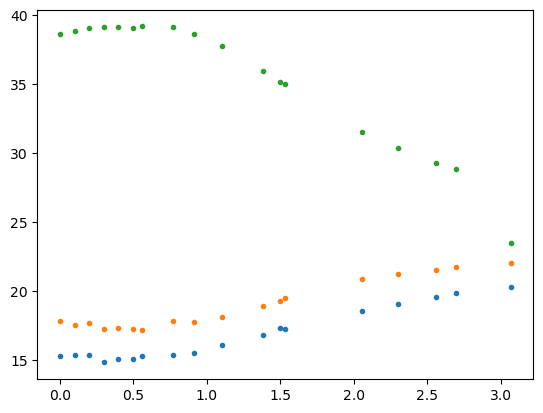

In [20]:
plt.plot(Ang,AA_r_Rigid,".")
plt.plot(Ang,AB_r_Rigid,".")
plt.plot(Ang,BA_r_Rigid,".")

plt.plot(Ang,AA_r_FixBN,".")
plt.plot(Ang,AB_r_FixBN,".")
plt.plot(Ang,BA_r_FixBN,".")

plt.plot(Ang,AA_r_Substrate,".")
plt.plot(Ang,AB_r_Substrate,".")
plt.plot(Ang,BA_r_Substrate,".")

plt.plot(Ang,AA_r_FullRelaxed,".")
plt.plot(Ang,AB_r_FullRelaxed,".")
plt.plot(Ang,BA_r_FullRelaxed,".")